Model head test - 50, 20, 15

In [ ]:
# Mount Google Drive
import os
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

# Set up dataset path
os.chdir("drive/My Drive/")
spreadsheet_path = "Auslan Static Dataset Breakdown"
dataset_path = "AuslanStaticData"

Mounted at /content/drive


In [ ]:
from google.colab import auth
auth.authenticate_user()

import gspread
from google.auth import default
creds, _ = default()

# Sheets access
gc = gspread.authorize(creds)

In [ ]:
import pandas as pd

worksheet = gc.open('Auslan Static Dataset Breakdown').sheet1

# Get all values from the worksheet
rows = worksheet.get_all_values()

# Convert to DataFrame with first row as column names
spreadsheet = pd.DataFrame(rows[1:], columns=rows[0])

print(spreadsheet)

     ID Subject         Date            Device        Filename Class Lighting  \
0     0    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_0_1.jpg     0  Natural   
1     1    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_1_1.jpg     1  Natural   
2     2    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_2_1.jpg     2  Natural   
3     3    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_3_1.jpg     3  Natural   
4     4    Nick   Feb 8 2025  Dell XPS 15 9050    Nick_4_1.jpg     4  Natural   
...  ..     ...          ...               ...             ...   ...      ...   
4729       Nick  Apr 29 2025         iPhone 12  Nick_u_114.JPG     u  Natural   
4730       Nick  Apr 29 2025         iPhone 12  Nick_u_115.JPG     u  Natural   
4731       Nick  Apr 29 2025         iPhone 12  Nick_u_116.JPG     u  Natural   
4732       Nick  Apr 29 2025         iPhone 12  Nick_u_117.JPG     u  Natural   
4733       Nick  Apr 29 2025         iPhone 12  Nick_u_118.JPG     u  Natural   

     Light level           

In [ ]:
# Get list of files
file_list = os.listdir(dataset_path)

# Convert to DataFrame
drive_files = pd.DataFrame(file_list, columns=['Filename'])

set1 = set(drive_files['Filename'])
set2 = set(spreadsheet["Filename"])

# Find missing files
missing_in_df2 = set1 - set2  # Files in df1 but not in df2
missing_in_df1 = set2 - set1  # Files in df2 but not in df1

print("Files missing in Spreadsheet:", missing_in_df2)
print("Files missing in Drive folder:", missing_in_df1)

print(set1)
print(set2)

Files missing in Spreadsheet: {'Evelyn_1_58.jpeg'}
Files missing in Drive folder: set()
{'Nick_a_112.jpg', 'Evelyn_a_23.jpg', 'Nick_0_106.jpg', 'Nick_1_116.JPG', 'Daniel_5_36.jpg', 'Nick_1_8.jpg', 'Luke_g_3.jpg', 'Nick_4_72.jpg', 'Daniel_a_4.jpg', 'Luke_a_27.jpg', 'Evelyn_2_26.jpg', 'Luke_1_43.JPG', 'Nick_2_90.jpg', 'Luke_3_9.jpg', 'Luke_7_14.jpg', 'Luke_3_14.jpg', 'Evelyn_u_46.JPG', 'Evelyn_u_70.jpg', 'Daniel_5_5.jpg', 'Evelyn_2_7.jpg', 'Nick_o_28.jpg', 'Nick_v_5.jpg', 'Nick_6_54.jpg', 'Daniel_4_39.jpg', 'Nick_5_1.jpg', 'Evelyn_2_27.jpg', 'Daniel_9_13.jpg', 'Nick_5_25.jpg', 'Evelyn_6_72.jpg', 'Luke_3_26.jpg', 'Nick_a_34.jpg', 'Luke_4_7.jpg', 'Evelyn_o_62.jpg', 'Nick_i_96.jpg', 'Luke_1_30.jpg', 'Luke_8_11.jpg', 'Evelyn_o_51.JPG', 'Evelyn_i_23.jpg', 'Nick_i_87.jpg', 'Evelyn_a_67.jpg', 'Luke_7_21.jpg', 'Daniel_4_35.jpg', 'Nick_e_100.jpg', 'Evelyn_2_9.jpg', 'Evelyn_2_36.jpg', 'Evelyn_3_43.jpg', 'Nick_2_28.jpg', 'Daniel_k_5.jpg', 'Nick_7_37.jpg', 'Nick_u_22.jpg', 'Nick_a_41.jpg', 'Luke_k_1

In [ ]:
# Create training and testing datasets that include and exclude specific images
import os
import pandas as pd
import shutil

vowel_numbers = ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', 'a', 'e', 'i', 'o', 'u']

# Files excluding independent variable
images = spreadsheet[spreadsheet['Class'].isin(vowel_numbers)]

filenames = images["Filename"]

training_images = filenames.sample(frac=0.7)  # Reduced to 70% for training
validation_images = filenames.drop(training_images.index).sample(frac=0.5) # 15% for validation
testing_images = filenames.drop(training_images.index).drop(validation_images.index) # 15% for testing


In [ ]:
# Extract class from filename
import re

def class_finder(filename):
    match = re.search(r'_(\w)_', filename)  # Extract the character between underscores
    if not match:
        raise ValueError("Filename format incorrect. Expected format: 'prefix_<char>_suffix'")

    extractFileClass = match.group(1)  # Get the matched class

    # Mapping for vowels
    class_map = {'a': 10, 'e': 11, 'i': 12, 'o': 13, 'u': 14}

    # Check if it's a digit
    if extractFileClass.isdigit():
        return int(extractFileClass)  # Convert string number to int
    elif extractFileClass in class_map:
        return class_map[extractFileClass]  # Map vowel to number
    else:
        raise ValueError(f"Unknown class: {extractFileClass}")  # Handle invalid cases

def label_generator(dataset_filenames):
    labels = []
    for filename in dataset_filenames:
        labels.append(class_finder(filename))
    return labels


In [ ]:
import tensorflow as tf

label_training = label_generator(training_images)
label_validation = label_generator(validation_images) # Generate validation labels
label_testing = label_generator(testing_images)

label_training = tf.keras.utils.to_categorical(label_training, num_classes=15)
label_validation = tf.keras.utils.to_categorical(label_validation, num_classes=15) # One-hot encode validation labels
label_testing = tf.keras.utils.to_categorical(label_testing, num_classes=15)

In [ ]:
# Create TF datasets from PD dataframes
def load_image(image_path):
    img = tf.io.read_file(os.path.join("AuslanStaticData", image_path.numpy().decode())) # Decode the image path from bytes to string
    img = tf.image.decode_jpeg(img, channels=3) # Decode the image
    img = tf.image.resize(img, [224, 224]) # Resize the image to your desired size
    img = tf.cast(img, tf.float32) # Cast the image to float32
    img = img / 255.0 # Normalize the pixel values to [0, 1]
    return img

def load_image_wrapper(image_path):
    img = tf.py_function(load_image, [image_path], Tout=tf.float32)
    img.set_shape([224, 224, 3])  # Set the shape immediately
    return img


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

training = tf.data.Dataset.from_tensor_slices((training_images.values, label_training)) # Create a dataset from the paths and labels
training = training.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
training = training.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching

validation = tf.data.Dataset.from_tensor_slices((validation_images.values, label_validation))
validation = validation.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
validation = validation.batch(32).prefetch(tf.data.AUTOTUNE)

testing = tf.data.Dataset.from_tensor_slices((testing_images.values, label_testing)) # Create a dataset from the paths and labels
testing = testing.map(lambda image_path, label: (load_image_wrapper(image_path), label), num_parallel_calls=tf.data.AUTOTUNE)
testing = testing.batch(32).prefetch(tf.data.AUTOTUNE) # Added batching and prefetching


In [ ]:
# Augment training datasets

import tensorflow as tf

def add_random_noise_with_factor(image, label):
    # Generate noise with mean 0 and stddev 1 (or adjust as needed)
    noise = tf.random.normal(shape=tf.shape(image), mean=0.0, stddev=1.0, dtype=tf.float32)

    # Generate a random noise_factor between 0.2 and 0.5
    noise_factor = tf.random.uniform(shape=[], minval=0.2, maxval=0.5)

    # Apply the noise with the random factor
    noisy_image = image + noise * noise_factor

    # Clip the pixel values to be within the valid range [0, 1]
    noisy_image = tf.clip_by_value(noisy_image, clip_value_min=0.0, clip_value_max=1.0)

    return noisy_image, label

flip_dataset = training.map(lambda image, label: (tf.image.stateless_random_flip_left_right(image, seed=(1,2)), label))  # Added seed argument
brightness_dataset = training.map(lambda image, label: (tf.image.random_brightness(image, max_delta=0.2), label))
contrast_dataset = training.map(lambda image, label: (tf.image.random_contrast(image, 0.8, 1.2), label))
saturation_dataset = training.map(lambda image, label: (tf.image.random_saturation(image, 0.8, 1.2), label))
noise_dataset = training.map(add_random_noise_with_factor, num_parallel_calls=tf.data.AUTOTUNE)


training = tf.data.Dataset.sample_from_datasets([training, flip_dataset, brightness_dataset, contrast_dataset, noise_dataset, saturation_dataset])


A. Surmenok, keras\_lr\_finder, GitHub repository. Available: https://github.com/surmenok/keras\_lr\_finder. Accessed: May 03, 2025.

In [ ]:
from matplotlib import pyplot as plt
import math
from keras.callbacks import LambdaCallback
import keras.backend as K
import numpy as np

import numpy as np

def set_value(x, value):
    value = np.asarray(value, dtype=x.dtype)  # Use x.dtype instead of x.dtype.name
    x.assign(value)

class LRFinder:
    """
    Plots the change of the loss function of a Keras model when the learning rate is exponentially increasing.
    See for details:
    https://towardsdatascience.com/estimating-optimal-learning-rate-for-a-deep-neural-network-ce32f2556ce0
    """

    def __init__(self, model):
        self.model = model
        self.losses = []
        self.lrs = []
        self.best_loss = 1e9

    def on_batch_end(self, batch, logs):
        # Log the learning rate
        lr = K.get_value(self.model.optimizer.learning_rate)
        self.lrs.append(lr)

        # Log the loss
        loss = logs['loss']
        self.losses.append(loss)

        # Check whether the loss got too large or NaN
        if batch > 5 and (math.isnan(loss) or loss > self.best_loss * 4):
            self.model.stop_training = True
            return

        if loss < self.best_loss:
            self.best_loss = loss

        # Increase the learning rate for the next batch
        lr *= self.lr_mult
        set_value(self.model.optimizer.learning_rate, lr)

    def find(self, x_train, y_train, start_lr, end_lr, batch_size=64, epochs=1, **kw_fit):
        # If x_train contains data for multiple inputs, use length of the first input.
        # Assumption: the first element in the list is single input; NOT a list of inputs.
        N = x_train[0].shape[0] if isinstance(x_train, list) else x_train.shape[0]

        # Compute number of batches and LR multiplier
        num_batches = epochs * N / batch_size
        self.lr_mult = (float(end_lr) / float(start_lr)) ** (float(1) / float(num_batches))
        # Save weights into a file
        initial_weights = self.model.get_weights()

        # Remember the original learning rate
        original_lr = K.get_value(self.model.optimizer.lr)

        # Set the initial learning rate
        K.set_value(self.model.optimizer.lr, start_lr)

        callback = LambdaCallback(on_batch_end=lambda batch, logs: self.on_batch_end(batch, logs))

        self.model.fit(x_train, y_train,
                       batch_size=batch_size, epochs=epochs,
                       callbacks=[callback],
                       **kw_fit)

        # Restore the weights to the state before model fitting
        self.model.set_weights(initial_weights)

        # Restore the original learning rate
        K.set_value(self.model.optimizer.lr, original_lr)

    def find_generator(self, generator, start_lr, end_lr, epochs=1, steps_per_epoch=None, **kw_fit):
        if steps_per_epoch is None:
            try:
                steps_per_epoch = len(generator)
            except (ValueError, NotImplementedError) as e:
                raise e('`steps_per_epoch=None` is only valid for a'
                        ' generator based on the '
                        '`keras.utils.Sequence`'
                        ' class. Please specify `steps_per_epoch` '
                        'or use the `keras.utils.Sequence` class.')
        self.lr_mult = (float(end_lr) / float(start_lr)) ** (float(1) / float(epochs * steps_per_epoch))

        # Save weights into a file
        initial_weights = self.model.get_weights()

        # Remember the original learning rate
        original_lr = K.get_value(self.model.optimizer.learning_rate)

        # Set the initial learning rate
        set_value(self.model.optimizer.learning_rate, start_lr)

        callback = LambdaCallback(on_batch_end=lambda batch,
                                                      logs: self.on_batch_end(batch, logs))

        self.model.fit(generator,
                                 epochs=epochs,
                                 steps_per_epoch=steps_per_epoch,
                                 callbacks=[callback],
                                 **kw_fit)

        # Restore the weights to the state before model fitting
        self.model.set_weights(initial_weights)

        # Restore the original learning rate
        set_value(self.model.optimizer.learning_rate, original_lr)

    def plot_loss(self, n_skip_beginning=10, n_skip_end=5, x_scale='log'):
        """
        Plots the loss.
        Parameters:
            n_skip_beginning - number of batches to skip on the left.
            n_skip_end - number of batches to skip on the right.
        """
        plt.ylabel("loss")
        plt.xlabel("learning rate (log scale)")
        plt.plot(self.lrs[n_skip_beginning:-n_skip_end], self.losses[n_skip_beginning:-n_skip_end])
        plt.xscale(x_scale)
        plt.show()

    def plot_loss_change(self, sma=1, n_skip_beginning=10, n_skip_end=5, y_lim=(-0.01, 0.01)):
        """
        Plots rate of change of the loss function.
        Parameters:
            sma - number of batches for simple moving average to smooth out the curve.
            n_skip_beginning - number of batches to skip on the left.
            n_skip_end - number of batches to skip on the right.
            y_lim - limits for the y axis.
        """
        derivatives = self.get_derivatives(sma)[n_skip_beginning:-n_skip_end]
        lrs = self.lrs[n_skip_beginning:-n_skip_end]
        plt.ylabel("rate of loss change")
        plt.xlabel("learning rate (log scale)")
        plt.plot(lrs, derivatives)
        plt.xscale('log')
        plt.ylim(y_lim)
        plt.show()

    def get_derivatives(self, sma):
        assert sma >= 1
        derivatives = [0] * sma
        for i in range(sma, len(self.lrs)):
            derivatives.append((self.losses[i] - self.losses[i - sma]) / sma)
        return derivatives

    def get_best_lr(self, sma, n_skip_beginning=10, n_skip_end=5):
        derivatives = self.get_derivatives(sma)
        best_der_idx = np.argmin(derivatives[n_skip_beginning:-n_skip_end])
        return self.lrs[n_skip_beginning:-n_skip_end][best_der_idx]

Epoch 1/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 95s 189ms/step - accuracy: 0.0653 - loss: 2.9767
Epoch 2/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - accuracy: 0.0711 - loss: 2.9299  
Epoch 3/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:151: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


456/456 ━━━━━━━━━━━━━━━━━━━━ 87s 191ms/step - accuracy: 0.0818 - loss: 2.8885
Epoch 4/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.1243 - loss: 2.7686 
Epoch 5/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 87s 191ms/step - accuracy: 0.1432 - loss: 2.6833
Epoch 6/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.2908 - loss: 2.2868 
Epoch 7/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 87s 191ms/step - accuracy: 0.2775 - loss: 2.2532
Epoch 8/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.3497 - loss: 1.9242 
Epoch 9/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 87s 190ms/step - accuracy: 0.1307 - loss: 2.6562
Epoch 10/10
456/456 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.1100 - loss: 2.6544 


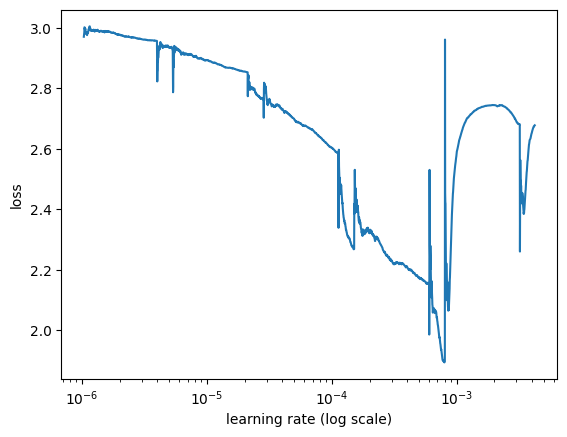

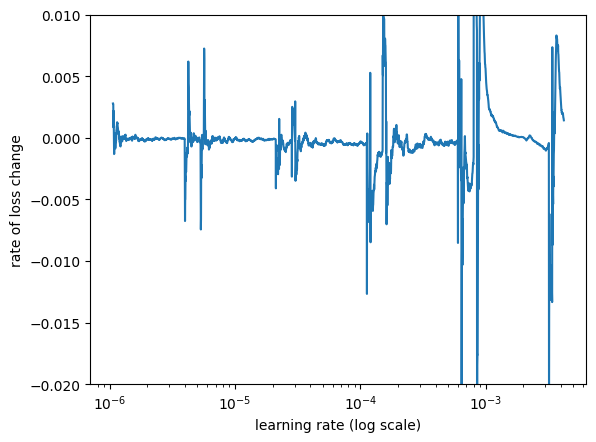

0.00085431646


In [ ]:
# Optimise learning rate
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.callbacks import EarlyStopping

# Define input shape based on dataset
IMG_SHAPE = (224, 224, 3)

base_model = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
# Unfreeze the last few convolutional layers
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(50, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(20, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

import numpy as np
K = tf.keras.backend

BATCH = 32


STEPS_PER_EPOCH = np.ceil(14585 / BATCH)
STEPS_PER_EPOCH = int(STEPS_PER_EPOCH)
lr_finder = LRFinder(model)
lr_finder.find_generator(training, start_lr=1e-6, end_lr=1, epochs=10,
                         steps_per_epoch=STEPS_PER_EPOCH)

lr_finder.plot_loss()
lr_finder.plot_loss_change(sma=20, n_skip_beginning=20, n_skip_end=5, y_lim=(-0.02, 0.01))

best_lr = lr_finder.get_best_lr(sma=20)

# Setting it as our model's LR through Keras Backend
set_value(model.optimizer.learning_rate, best_lr)
print(best_lr)

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, regularizers # Import regularizers here
from tensorflow.keras.callbacks import EarlyStopping

# Define input shape based on dataset
IMG_SHAPE = (224, 224, 3)

base_model = VGG16(weights="imagenet", include_top=False, input_shape=IMG_SHAPE)
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(50, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.5),
    layers.BatchNormalization(),
    layers.Dense(20, activation='relu', kernel_regularizer=regularizers.l2(0.001)),
    layers.Dense(15, activation='softmax')
    ])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

optimizer = tf.keras.optimizers.Adam(learning_rate=float(best_lr))

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

es_1 = EarlyStopping(monitor='val_accuracy', mode='max', patience=10,  restore_best_weights=True)
model.fit(training, epochs=200, batch_size=32,validation_data=validation, callbacks=[es_1])

Epoch 1/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 115s 197ms/step - accuracy: 0.0681 - loss: 2.8530 - val_accuracy: 0.0656 - val_loss: 2.7731
Epoch 2/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 103s 186ms/step - accuracy: 0.0664 - loss: 2.7349 - val_accuracy: 0.0656 - val_loss: 2.7377
Epoch 3/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 103s 186ms/step - accuracy: 0.0751 - loss: 2.7250 - val_accuracy: 0.0832 - val_loss: 2.7074
Epoch 4/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 103s 186ms/step - accuracy: 0.1202 - loss: 2.5307 - val_accuracy: 0.1200 - val_loss: 2.1610
Epoch 5/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 103s 186ms/step - accuracy: 0.1671 - loss: 2.1919 - val_accuracy: 0.2176 - val_loss: 1.8983
Epoch 6/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 103s 186ms/step - accuracy: 0.2263 - loss: 2.0352 - val_accuracy: 0.2736 - val_loss: 1.7247
Epoch 7/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 103s 186ms/step - accuracy: 0.2730 - loss: 1.8491 - val_accuracy: 0.3744 - val_loss: 1.5561
Epoch 8/200
552/552 ━━━━━━━━━━━━━━━━━━━━ 103s 187ms/step - accuracy: 

In [ ]:
# Produce confusion matrix for included model tested on independent variable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Produce confusion matrix for included model tested on independent variable
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Predict on the test set using the model
pred_1 = model.predict(testing, verbose=1)

# Get the predicted labels by taking the index of the maximum probability for each image
pred_1_labels = np.argmax(pred_1, axis=1)

# Get the true labels from the test set generator
pred_1_true = np.concatenate([y.numpy() for _, y in testing.unbatch()])

# Reshape into (N, 15) where N is inferred
pred_1_true = pred_1_true.reshape(-1, 15)

# Apply argmax to get class labels
pred_1_true = np.argmax(pred_1_true, axis=1)

# Generate the confusion matrix
cm_1 = confusion_matrix(pred_1_true, pred_1_labels)

20/20 ━━━━━━━━━━━━━━━━━━━━ 6s 262ms/step


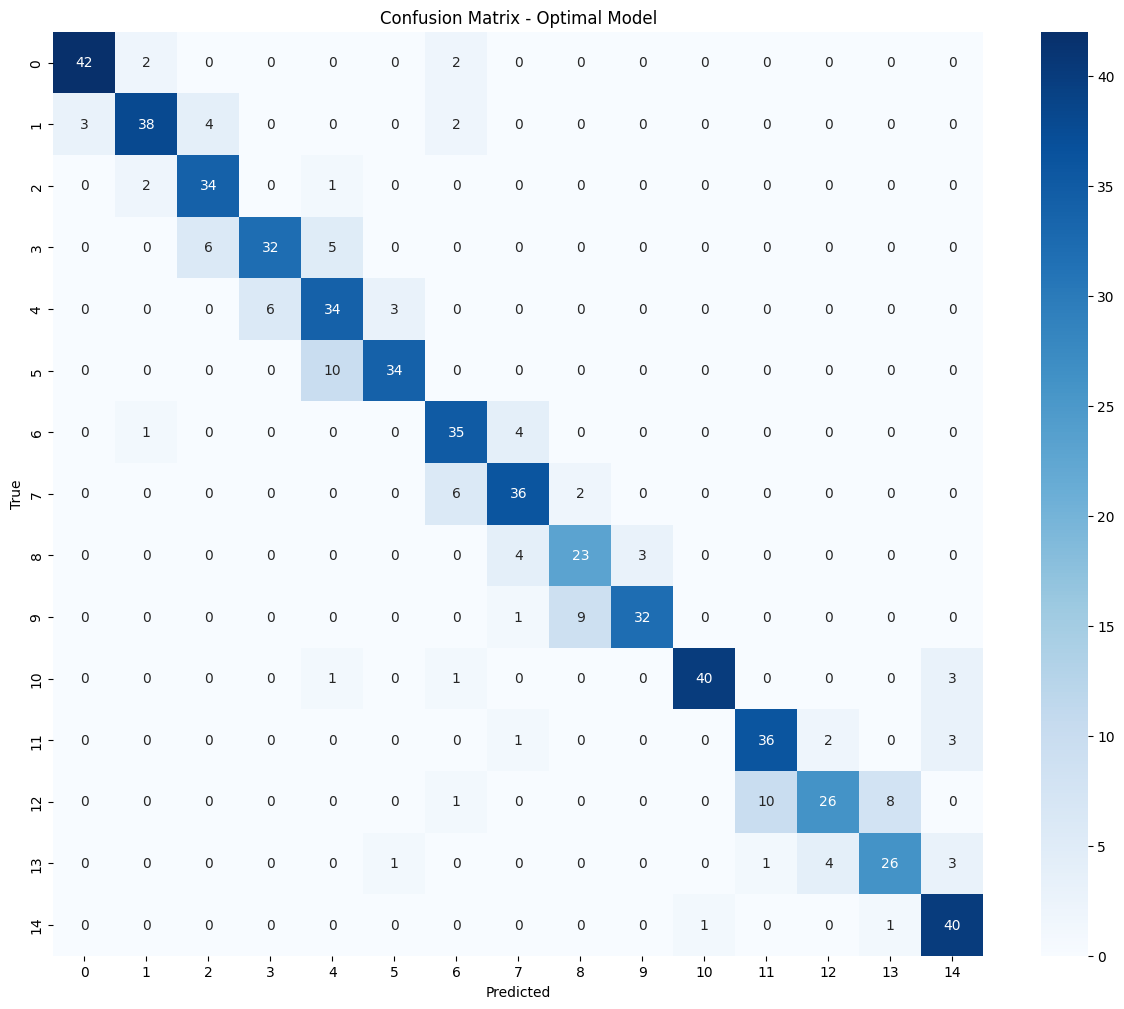

In [ ]:
# Define the confusion matrices and titles for plotting
confusion_matrices = [cm_1]
titles = ['Optimal Model']

# Generate the confusion matrix
cm_1 = confusion_matrix(pred_1_true, pred_1_labels)

# Plot the confusion matrix using seaborn
plt.figure(figsize=(15, 12))  # Adjust figure size as needed
sns.heatmap(cm_1, annot=True, fmt='d', cmap='Blues',
            xticklabels=[str(i) for i in range(cm_1.shape[1])],
            yticklabels=[str(i) for i in range(cm_1.shape[0])])
plt.title('Confusion Matrix - Optimal Model')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [ ]:
print("Optimal Model")
print(classification_report(pred_1_true, pred_1_labels))

Optimal Model
              precision    recall  f1-score   support

           0       0.93      0.91      0.92        46
           1       0.88      0.81      0.84        47
           2       0.77      0.92      0.84        37
           3       0.84      0.74      0.79        43
           4       0.67      0.79      0.72        43
           5       0.89      0.77      0.83        44
           6       0.74      0.88      0.80        40
           7       0.78      0.82      0.80        44
           8       0.68      0.77      0.72        30
           9       0.91      0.76      0.83        42
          10       0.98      0.89      0.93        45
          11       0.77      0.86      0.81        42
          12       0.81      0.58      0.68        45
          13       0.74      0.74      0.74        35
          14       0.82      0.95      0.88        42

    accuracy                           0.81       625
   macro avg       0.81      0.81      0.81       625
weighted avg